# K-Means Clustering

![Workflow K-Means Clustering](../../img/polutan/kmeans.png)

## Dokumentasi Workflow (KNIME)

Workflow di atas merupakan rancangan proses klasterisasi menggunakan algoritma K-Means yang membandingkan dua eksperimen utama: **tanpa reduksi dimensi** dan **dengan reduksi dimensi (PCA)**. Masing-masing eksperimen diuji dengan jumlah klaster (k) sebanyak 3 dan 5.

Berikut adalah penjelasan fungsi untuk setiap node yang digunakan:

1. **MySQL Connector**
   Berfungsi untuk membangun koneksi dari KNIME ke server database MySQL menggunakan kredensial (host, port, database, username, password) yang sesuai.

2. **DB Table Selector**
   Menyeleksi atau memilih tabel spesifik (beserta kolom-kolomnya melalui query SQL jika diperlukan) di dalam database MySQL yang berisi data mentah polutan.

3. **DB Reader**
   Mengeksekusi query dari DB Table Selector dan menarik (import) data mentah tersebut dari database ke dalam memori/environment KNIME agar dapat diproses pada node-node selanjutnya.
   
4. **Column Filter**
   Menyeleksi fitur-fitur yang akan digunakan dalam pemodelan. Pada kasus ini, node ini digunakan secara spesifik untuk **menghilangkan kolom id** karena kolom tersebut tidak memiliki nilai analitik untuk proses klasterisasi.

5. **PCA (Principal Component Analysis)**
   **PCA** adalah teknik reduksi dimensi yang digunakan untuk menyederhanakan kompleksitas data berdimensi tinggi (memiliki banyak atribut/kolom) sambil tetap mempertahankan informasi penting sebanyak mungkin. PCA bekerja dengan mentransformasikan fitur-fitur asli yang mungkin saling berkorelasi menjadi sekumpulan variabel baru yang tidak saling berkorelasi (independen), yang disebut **Principal Components (Komponen Utama)**.
   
   Pada eksperimen ini, PCA secara spesifik digunakan untuk mengatasi masalah *curse of dimensionality* (kutukan dimensi) akibat banyaknya jumlah fitur. Sesuai dengan keterangan pada workflow, node ini berhasil **mereduksi dimensi dari 68 fitur awal menjadi hanya 37 komponen utama**. 
   
   Penerapan PCA dalam alur K-Means sangat bermanfaat karena:
   - **Meningkatkan performa K-Means:** K-Means mengelompokkan data berdasarkan jarak (seperti jarak Euclidean). Pada dimensi yang terlalu tinggi, jarak antar semua titik cenderung menjadi sama, membuat klastering tidak efektif.
   - **Efisiensi komputasi:** Lebih sedikit dimensi berarti waktu eksekusi perhitungan akan lebih cepat.
   - **Menghilangkan Noise:** PCA membantu menyaring fitur-fitur yang tidak relevan yang berpotensi merusak hasil klaster.
   
6. **k-Means**
   Algoritma inti yang bertugas mengelompokkan data ke dalam *k* klaster. Pada workflow ini, K-Means dijalankan dalam 4 skenario berbeda:
   - Klastering dengan 3 klaster (menggunakan data asli tanpa PCA).
   - Klastering dengan 5 klaster (menggunakan data asli tanpa PCA).
   - Klastering dengan 3 klaster (menggunakan 37 komponen hasil PCA).
   - Klastering dengan 5 klaster (menggunakan 37 komponen hasil PCA).

7. **Silhouette Coefficient**
   Metrik evaluasi yang digunakan untuk mengukur seberapa baik setiap titik data dikelompokkan ke dalam klasternya sendiri dibandingkan dengan klaster lain. Nilai yang mendekati 1 menunjukkan klastering yang baik.

8. **Table View**
   Node visualisasi yang menampilkan nilai Silhouette Coefficient untuk masing-masing data dalam format tabel interaktif. Node ini juga menunjukkan ringkasan rata-rata (Mean). Berdasarkan gambar, performa terbaik didapat pada pembagian 3 klaster dengan rata-rata **Mean = 0.658**.

9. **Scatter Plot**
   Node visualisasi untuk membuat grafik pencar yang memperlihatkan persebaran titik-titik data berdasarkan klaster yang terbentuk, sehingga kita bisa melihat batas (separasi) antar klaster secara visual.

---

## Hasil Evaluasi dan Visualisasi per Skenario

Pada bagian ini, evaluasi pembentukan klaster (diukur menggunakan rata-rata *Silhouette Coefficient*) dan visualisasinya (menggunakan *Scatter Plot*) dibagi ke dalam empat eksperimen yang berbeda.

### 1. Klastering 3 Kelas (Tanpa PCA)
*Tabel Silhouette Coefficient untuk k=3 tanpa PCA:*

```{image} ../../img/polutan/3-tanpa.png
:alt: Workflow K-Means Clustering
:width: 100%
:align: center
:class: mabot-gambar
```

*Visualisasi Scatter Plot untuk k=3 tanpa PCA:*
```{image} ../../img/polutan/sct-3.png
:alt: Workflow K-Means Clustering
:width: 100%
:align: center
:class: mabot-gambar
```

*Implementasi code python:*

Inertia: 1001.2819

Jumlah data per cluster:
cluster_label
cluster_0    20
cluster_1     1
cluster_2    16
Name: count, dtype: int64


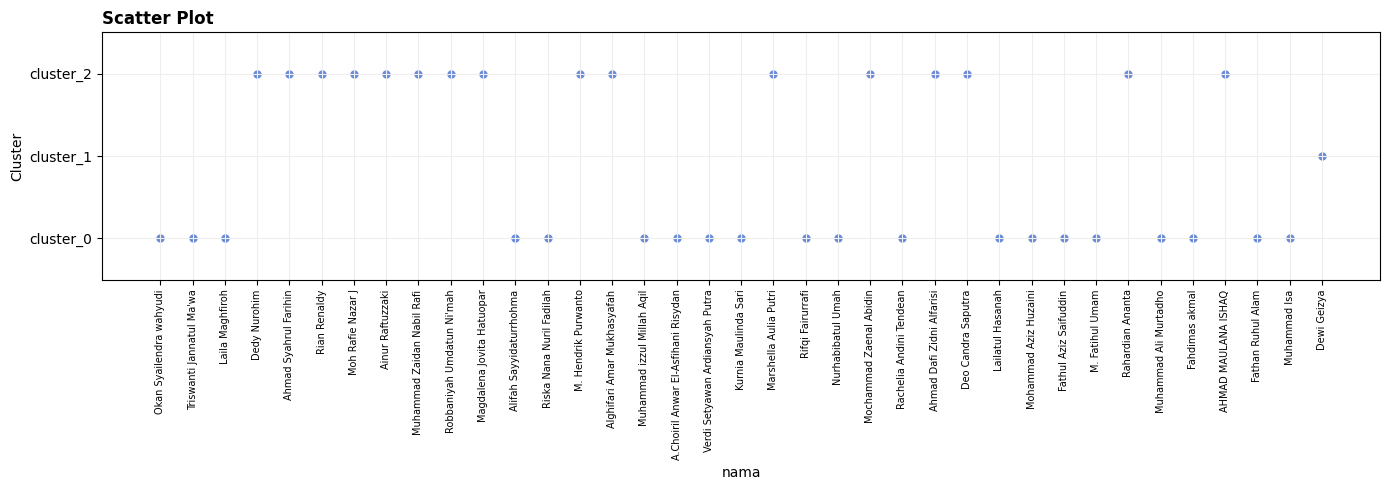

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


CSV_PATH = "../../Data/polutan/ekstraksi_fitur_no2.csv"                      
KOLOM_NAMA = "nama"                         
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()       

K = 3                                      
GUNAKAN_SCALING = True                    

# 1. Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()

# 2. Standarisasi (opsional)
if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# 3. K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# 4. Hasil 
print(f"Inertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# 5. Scatter plot: nama (sumbu X) vs cluster (sumbu Y)
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()


### 2. Klastering 5 Kelas (Tanpa PCA)

*Tabel Silhouette Coefficient untuk k=5 tanpa PCA:*

```{image} ../../img/polutan/5-tanpa.png
:alt: Workflow K-Means Clustering
:width: 100%
:align: center
:class: mabot-gambar
```

*Visualisasi Scatter Plot untuk k=5 tanpa PCA:*

```{image} ../../img/polutan/sct-5.png
:alt: Workflow K-Means Clustering
:width: 100%
:align: center
:class: mabot-gambar
```

*Implementasi code python:*

Inertia: 655.7898

Jumlah data per cluster:
cluster_label
cluster_0     2
cluster_1    22
cluster_2     1
cluster_3     1
cluster_4    11
Name: count, dtype: int64


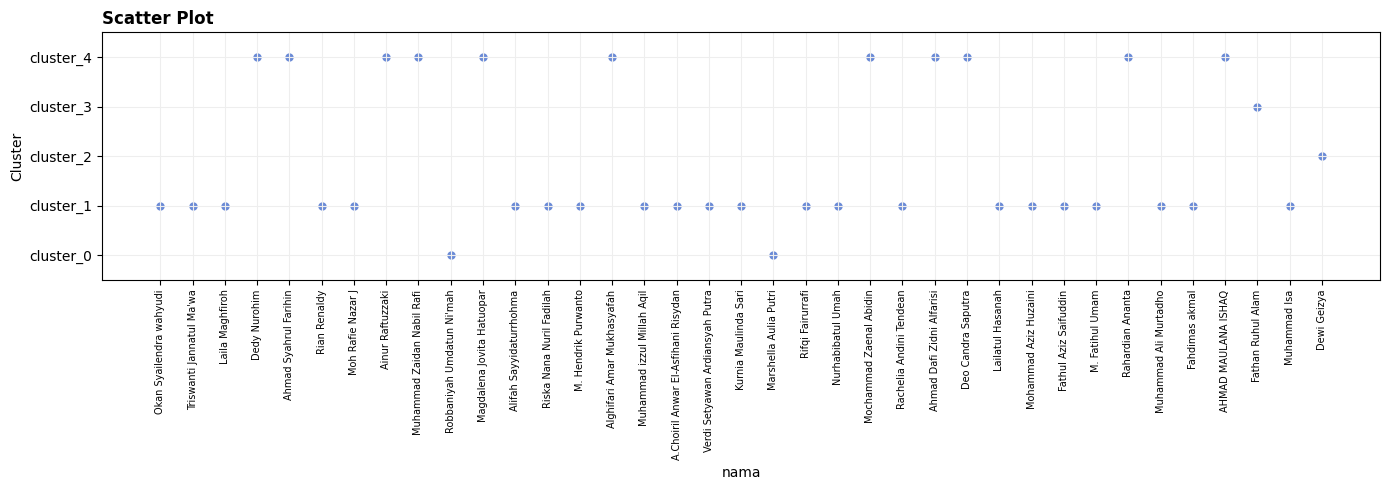

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


CSV_PATH = "../../Data/polutan/ekstraksi_fitur_no2.csv"                      
KOLOM_NAMA = "nama"                         
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()       

K = 5                                      
GUNAKAN_SCALING = True                    

# 1. Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()

# 2. Standarisasi
if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# 3. K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# 4. Hasil 
print(f"Inertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())
x
# 5. Scatter plot: nama (sumbu X) vs cluster (sumbu Y)
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()


### 3. Klastering 3 Kelas (Dengan PCA)

*Tabel Silhouette Coefficient untuk k=3 dengan PCA:*

```{image} ../../img/polutan/3-pca.png
:alt: Workflow K-Means Clustering
:width: 100%
:align: center
:class: mabot-gambar
```

*Visualisasi Scatter Plot untuk k=3 dengan PCA:*

```{image} ../../img/polutan/sct-3-pca.png
:alt: Workflow K-Means Clustering
:width: 100%
:align: center
:class: mabot-gambar
```

*Implementasi code python:*

PCA: 68 fitur -> 37 dimensi

Inertia: 1001.2819

Jumlah data per cluster:
cluster_label
cluster_0    20
cluster_1     1
cluster_2    16
Name: count, dtype: int64


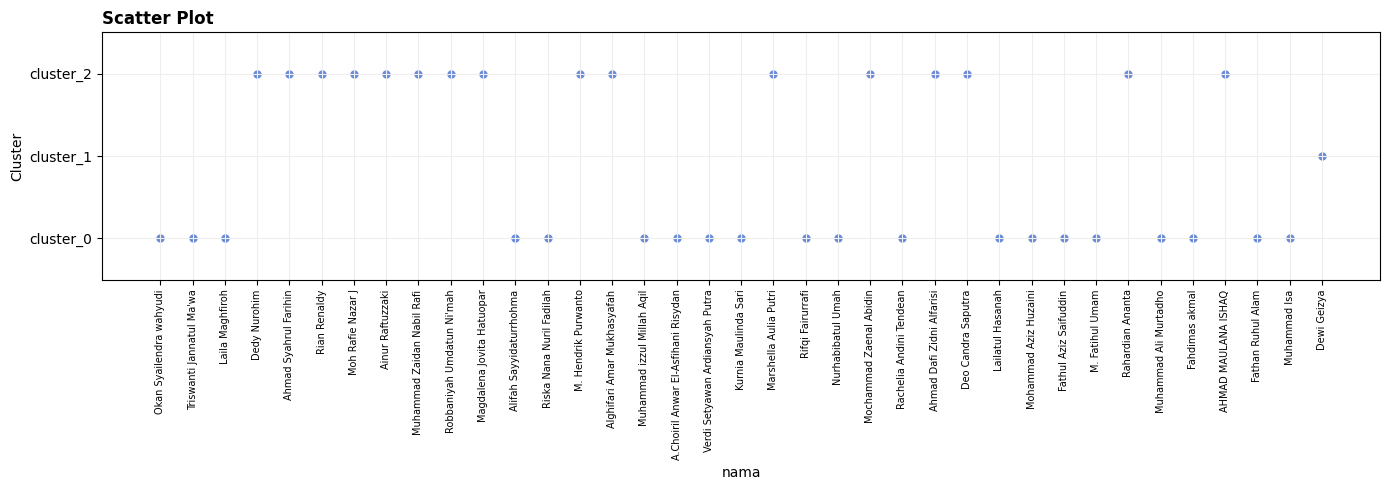

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CSV_PATH = "../../Data/polutan/ekstraksi_fitur_no2.csv"               
KOLOM_NAMA = "nama"                               
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()
K = 3
N_DIMENSI = 37
GUNAKAN_SCALING = True

if N_DIMENSI > len(KOLOM_FITUR):
    raise ValueError(
        f"N_DIMENSI ({N_DIMENSI}) tidak boleh lebih besar dari jumlah fitur ({len(KOLOM_FITUR)})."
    )

#  Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()


if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# PCA
pca = PCA(n_components=N_DIMENSI, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA: {len(KOLOM_FITUR)} fitur -> {N_DIMENSI} dimensi")

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# Hasil
print(f"\nInertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# Scatter plot
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()


### 4. Klastering 5 Kelas (Dengan PCA)

*Tabel Silhouette Coefficient untuk k=5 dengan PCA:*

```{image} ../../img/polutan/5-pca.png
:alt: Workflow K-Means Clustering
:width: 100%
:align: center
:class: mabot-gambar
```

*Visualisasi Scatter Plot untuk k=5 dengan PCA:*

```{image} ../../img/polutan/sct-5-pca.png
:alt: Workflow K-Means Clustering
:width: 100%
:align: center
:class: mabot-gambar
```

*Implementasi code Python:*

PCA: 68 fitur -> 37 dimensi

Inertia: 655.7898

Jumlah data per cluster:
cluster_label
cluster_0     2
cluster_1    22
cluster_2     1
cluster_3     1
cluster_4    11
Name: count, dtype: int64


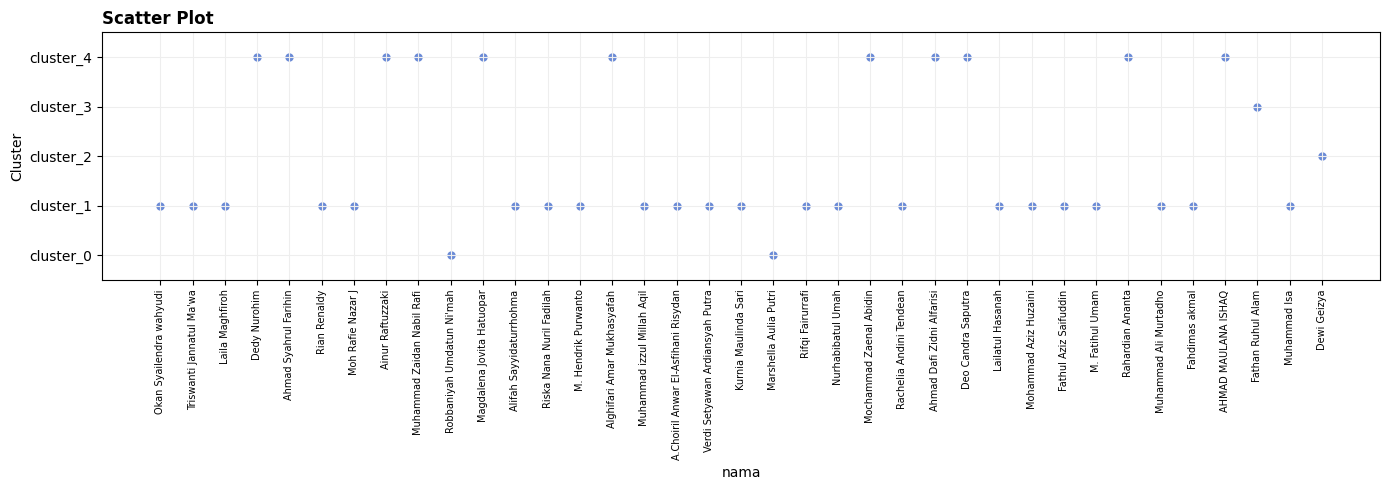

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CSV_PATH = "../../Data/polutan/ekstraksi_fitur_no2.csv"               
KOLOM_NAMA = "nama"                               
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()
K = 5
N_DIMENSI = 37
GUNAKAN_SCALING = True

if N_DIMENSI > len(KOLOM_FITUR):
    raise ValueError(
        f"N_DIMENSI ({N_DIMENSI}) tidak boleh lebih besar dari jumlah fitur ({len(KOLOM_FITUR)})."
    )

#  Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()


if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# PCA
pca = PCA(n_components=N_DIMENSI, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA: {len(KOLOM_FITUR)} fitur -> {N_DIMENSI} dimensi")

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# Hasil
print(f"\nInertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# Scatter plot
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()


---

## Kesimpulan

Berdasarkan rancangan eksperimen klasterisasi menggunakan algoritma K-Means di atas, dapat ditarik beberapa kesimpulan utama:

1. **Jumlah Klaster Optimal (k=3):** Pembagian data menjadi 3 klaster menghasilkan performa yang jauh lebih baik dibandingkan dengan 5 klaster. Hal ini dibuktikan dari rata-rata nilai **Silhouette Coefficient sebesar 0.658** (mendekati 1, yang mengindikasikan struktur klaster yang sangat baik dan terpisah dengan jelas) untuk k=3. Sedangkan untuk k=5, nilainya turun drastis menjadi **0.633**, yang menandakan bahwa batas antar klaster menjadi ambigu atau tumpang tindih.
2. **Efektivitas PCA:** Penggunaan PCA berhasil mereduksi dimensi data secara signifikan dari 68 fitur awal menjadi hanya 37 komponen utama. Menariknya, reduksi ini tidak menurunkan kualitas klasterisasi secara keseluruhan. Sebaliknya, PCA membantu mengurangi beban komputasi dan kompleksitas data (*curse of dimensionality*) sambil tetap mempertahankan informasi penting yang dibutuhkan oleh K-Means untuk membentuk klaster yang valid.